# Analyzing log files

In [22]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

# --- 1. Parsing ---

def parse_coev_log(log_file_path: str, target_run_id: str, target_problem_id: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Parses the coevolution log file, filtering for a specific
    run_id and problem_id.
    """
    generation_data = []
    individual_data = []

    # --- NEW: Create the expected prefix to check against ---
    expected_prefix = f"[{target_run_id}:{target_problem_id}]"

    with open(log_file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('|')
            
            # --- NEW FILTER ---
            # If the line doesn't have at least 2 parts, or if the 
            # second part doesn't match our target, skip the line.
            if len(parts) < 2 or parts[1].strip() != expected_prefix:
                continue
            # --- END FILTER ---

            # Now, proceed with the original parsing logic, knowing
            # this line belongs to our target run.
            if len(parts) < 5:
                continue

            log_key = parts[2].strip()
            
            try:
                if log_key == "GEN_SUMMARY":
                    payload_str = parts[4].strip()
                    data = json.loads(payload_str)
                    generation_data.append(data)
                
                elif log_key in ["INDIVIDUAL_DIED", "INDIVIDUAL_SURVIVED"]:
                    payload_str = parts[4].strip()
                    data = json.loads(payload_str)
                    data['status'] = log_key.split('_')[-1]
                    individual_data.append(data)

            except json.JSONDecodeError as e:
                print(f"Skipping line due to JSON error: {e}\nLine: {line}")
            except Exception as e:
                print(f"Error processing line: {e}\nLine: {line}")

    # --- 2. Structuring Data ---
    gen_df = pd.DataFrame(generation_data)
    if not gen_df.empty:
        gen_df = gen_df.set_index('generation')
        
    ind_df = pd.DataFrame(individual_data)
    if not ind_df.empty:
        # Add the run/problem ID to the dataframes for clarity
        ind_df['run_id'] = target_run_id
        ind_df['problem_id'] = target_problem_id

    return gen_df, ind_df

# --- 3. Analysis ---

def plot_fitness_dynamics(gen_df: pd.DataFrame) -> None:
    """
    Plots the average, min, and max probabilities for both populations.
    """
    if gen_df.empty:
        print("Generation summary DataFrame is empty. Skipping plot.")
        return

    print("--- Plotting Population Fitness Dynamics ---")
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot average probabilities
    gen_df['avg_code_prob'].plot(ax=ax, label='Avg. Code Prob.', color='blue', lw=2)
    gen_df['avg_test_prob'].plot(ax=ax, label='Avg. Test Prob.', color='red', lw=2)


    ax.set_title('Coevolutionary Fitness Dynamics')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Probability (Fitness)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def analyze_survivors(ind_df: pd.DataFrame) -> None:
    """
    Prints a summary of the final surviving individuals.
    """
    if ind_df.empty:
        print("Individual DataFrame is empty. Skipping survivor analysis.")
        return
        
    print("\n--- Final Survivors ---")
    survivors = ind_df[ind_df['status'] == 'SURVIVED'].sort_values('probability', ascending=False)
    
    if survivors.empty:
        print("No survivors found.")
        return

    for _, ind in survivors.iterrows():
        print(f"ID: {ind['id']} ({ind['type']})")
        print(f"  Probability: {ind['probability']:.4f}")
        print(f"  Born: Gen {ind['generation_born']}")
        print(f"  Parents: {ind['parent_ids']} (Op: {ind['creation_op']})")
        # Print a snippet preview
        snippet_preview = ind['snippet'].split('\n')[0]
        print(f"  Snippet: {snippet_preview}...")

def build_lineage_graph(ind_df: pd.DataFrame) -> nx.DiGraph:
    """
    Builds and returns a NetworkX graph of the full lineage.
    """
    if ind_df.empty:
        print("Individual DataFrame is empty. Skipping lineage graph.")
        return None

    print("\n--- Building Lineage Graph ---")
    G = nx.DiGraph()

    for _, row in ind_df.iterrows():
        # Add the node with its attributes
        G.add_node(
            row['id'],
            type=row['type'],
            status=row['status'],
            prob=row['probability'],
            gen_born=row['generation_born'],
            op=row['creation_op']
        )
        
        # Add edges from its parents
        for parent in row['parent_ids']:
            # Ensure parent node exists (in case it's not in the log)
            if not G.has_node(parent):
                G.add_node(parent, type='Unknown', status='Unknown')
            
            G.add_edge(parent, row['id'])
            
    print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
    return G



def visualize_lineage(G) -> None:
    """
    Creates a detailed plot of the coevolution lineage DiGraph
    using a top-down hierarchical layout.
    
    This version MANUALLY calculates the layout without pygraphviz.
    
    Assumes G nodes have 'status' and 'gen_born' attributes.
    """
    if G is None or G.number_of_nodes() == 0:
        print("Graph is empty, nothing to visualize.")
        return

    print("Generating lineage visualization (manual layout)...")
    plt.figure(figsize=(16, 12))

    # 1. Create a color map based on node type
    color_map = []
    for node in G:
        node_data = G.nodes[node]
        if node_data.get('status') == 'SURVIVED':
            color_map.append('skyblue')
        elif node_data.get('status') == 'DIED':
            color_map.append('salmon')
        else:
            color_map.append('lightgray') 

    # --- 3. Manually compute a hierarchical layout ---
    
    pos = {}
    
    # Get all nodes that have a generation (ignore 'Unknown' parents)
    nodes_with_gen = [
        (n, d['gen_born']) for n, d in G.nodes(data=True) if 'gen_born' in d
    ]
    
    if not nodes_with_gen:
        print("No nodes have 'gen_born' attribute. Falling back to spring_layout.")
        pos = nx.spring_layout(G)
    else:
        # 1. Group nodes by generation
        gen_to_nodes = defaultdict(list)
        for node, gen in nodes_with_gen:
            gen_to_nodes[gen].append(node)
            
        # 2. Assign positions
        x_spacing = 1.0
        y_spacing = -1.0 # Puts gen 0 at the top
        
        for gen, nodes in sorted(gen_to_nodes.items()):
            num_nodes = len(nodes)
            # Center the nodes in this generation on the x-axis
            start_x = - (num_nodes - 1) * x_spacing / 2.0
            
            for i, node in enumerate(nodes):
                pos[node] = (start_x + i * x_spacing, gen * y_spacing)

    # 4. Draw the graph components
    nx.draw_networkx_nodes(
        G, 
        pos, 
        node_color=color_map, 
        alpha=0.9
    )
    
    nx.draw_networkx_edges(
        G, 
        pos, 
        width=1.0, 
        alpha=0.2, 
        edge_color='gray', 
        arrows=True,
        # Improve edge drawing for manual layout
        connectionstyle='arc3,rad=0.1' 
    )
    
    nx.draw_networkx_labels(
        G, 
        pos, 
        font_size=9, 
        font_weight='bold'
    )
    
    plt.title("Coevolution Lineage Graph (Top-Down Layout)", fontsize=20)
    plt.legend(
        handles=[
            plt.Line2D([0], [0], marker='o', color='w', label='Survivor',
                       markerfacecolor='skyblue', markersize=15),
            plt.Line2D([0], [0], marker='o', color='w', label='Died',
                       markerfacecolor='salmon', markersize=15),
        ],
        title="Legend"
    )
    plt.axis('off') 
    plt.tight_layout()
    plt.show()

Skipping line due to JSON error: Unterminated string starting at: line 1 column 52 (char 51)
Line: 2025-11-12 12:04:01.182 | [test_012:3233] | INDIVIDUAL_DIED|T45|{"id": "T45", "type": "TestIndividual", "snippet": "def test_greedy_fails_when_k_equals_distinct_and_change_reduces_prefix_length(self):\n    # This test exposes bugs in the naive brute-force replacement + greedy partitioning:\n    # - The helper partitions() closes over n (original length) and doesn't adapt if a string of different length\n    #   were ever used (not an issue here), but more importantly the greedy partition logic is flawed for some cases.\n    # - The brute-force tries all single-character changes but may produce incorrect partition counts due to the\n    #   greedy inner loop incorrectly allowing more characters than allowed in a prefix for certain arrangements.\n    # The case below requires carefully evaluating prefixes after a change to maximize the number of partitions.\n    s = \"abacaba\"\n    k = 2\n

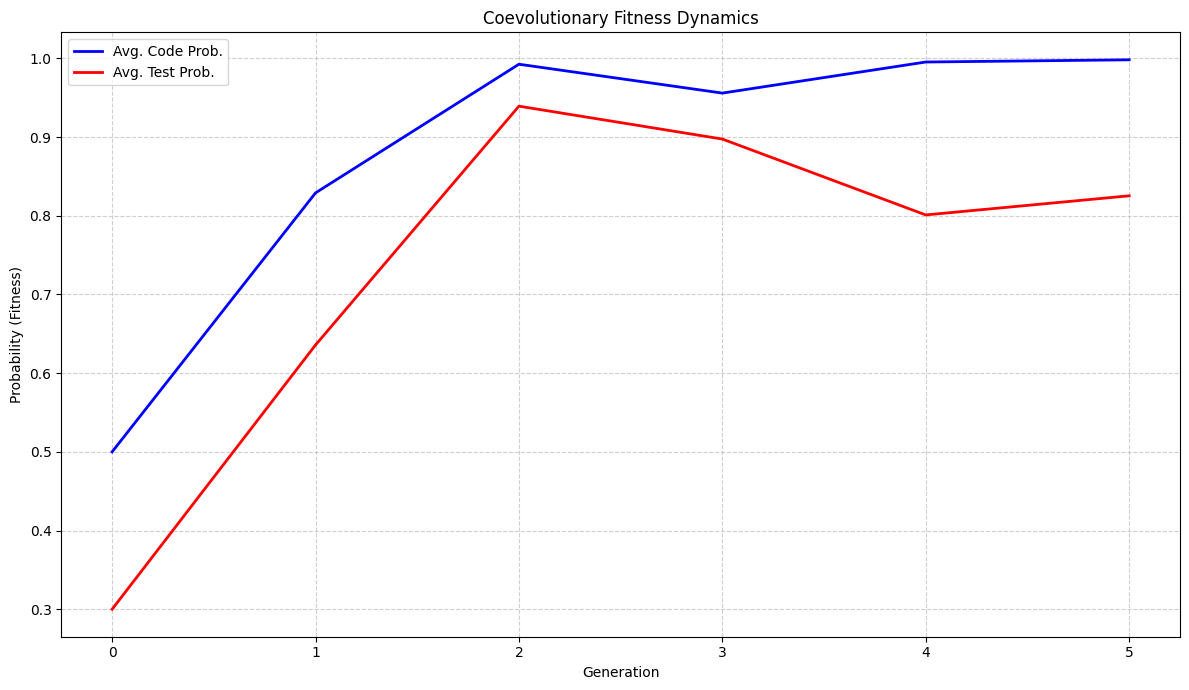


--- Final Survivors ---
ID: C34 (CodeIndividual)
  Probability: 1.0000
  Born: Gen 4
  Parents: ['C17'] (Op: mutation)
  Snippet: class Solution:...
ID: C11 (CodeIndividual)
  Probability: 1.0000
  Born: Gen 1
  Parents: ['C0'] (Op: edit)
  Snippet: class Solution:...
ID: C12 (CodeIndividual)
  Probability: 1.0000
  Born: Gen 1
  Parents: ['C1'] (Op: edit)
  Snippet: class Solution:...
ID: C43 (CodeIndividual)
  Probability: 1.0000
  Born: Gen 5
  Parents: ['C34', 'C11'] (Op: crossover)
  Snippet: class Solution:...
ID: C40 (CodeIndividual)
  Probability: 1.0000
  Born: Gen 5
  Parents: ['C31'] (Op: edit)
  Snippet: class Solution:...
ID: C42 (CodeIndividual)
  Probability: 1.0000
  Born: Gen 5
  Parents: ['C24'] (Op: edit)
  Snippet: from collections import defaultdict...
ID: C0 (CodeIndividual)
  Probability: 1.0000
  Born: Gen 0
  Parents: [] (Op: initial)
  Snippet: class Solution:...
ID: C24 (CodeIndividual)
  Probability: 1.0000
  Born: Gen 3
  Parents: ['C20'] (Op: reproduction

In [27]:
LOG_FILE = '../../../logs/generations/coevolution_run_20251112.log'
    
RUN_TO_ANALYZE = 'test_012'
PROBLEM_TO_ANALYZE = '3233'

try:
    # Pass the targets to the parsing function
    gen_df, ind_df = parse_coev_log(
        LOG_FILE, 
        RUN_TO_ANALYZE, 
        PROBLEM_TO_ANALYZE
    )
    
    print(f"--- Analysis for Run: {RUN_TO_ANALYZE}, Problem: {PROBLEM_TO_ANALYZE} ---")

    if gen_df.empty and ind_df.empty:
        print("No matching data found.")
    
    else:
        if not gen_df.empty:
            print("\n--- Generation Summary (Head) ---")
            print(gen_df.head())
        
        if not ind_df.empty:
            print("\n--- Individual Data (Head) ---")
            print(ind_df[['id', 'type', 'status', 'generation_born']].head())
                
        plot_fitness_dynamics(gen_df)
        analyze_survivors(ind_df)
        lineage_graph = build_lineage_graph(ind_df)

except FileNotFoundError:
    print(f"Error: Log file not found at '{LOG_FILE}'")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [28]:
ind_df.head()

,id,type,snippet,creation_op,generation_born,probability,parent_ids,lifecycle_events,status,run_id,problem_id
0,C2,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,0.7960,[],"[{'generation': 0, 'event': 'created', 'detail...",DIED,test_012,3233
1,C4,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,0.7165,[],"[{'generation': 0, 'event': 'created', 'detail...",DIED,test_012,3233
2,C6,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,0.2378,[],"[{'generation': 0, 'event': 'created', 'detail...",DIED,test_012,3233
3,C7,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,0.8189,[],"[{'generation': 0, 'event': 'created', 'detail...",DIED,test_012,3233
4,C9,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,0.4780,[],"[{'generation': 0, 'event': 'created', 'detail...",DIED,test_012,3233


In [29]:
code_ind_df = ind_df[ind_df['type'] == 'CodeIndividual']
test_ind_df = ind_df[ind_df['type'] == 'TestIndividual']
code_G = build_lineage_graph(code_ind_df)
test_G = build_lineage_graph(test_ind_df)


--- Building Lineage Graph ---
Graph created with 45 nodes and 43 edges.

--- Building Lineage Graph ---
Graph created with 85 nodes and 80 edges.


Generating lineage visualization (manual layout)...


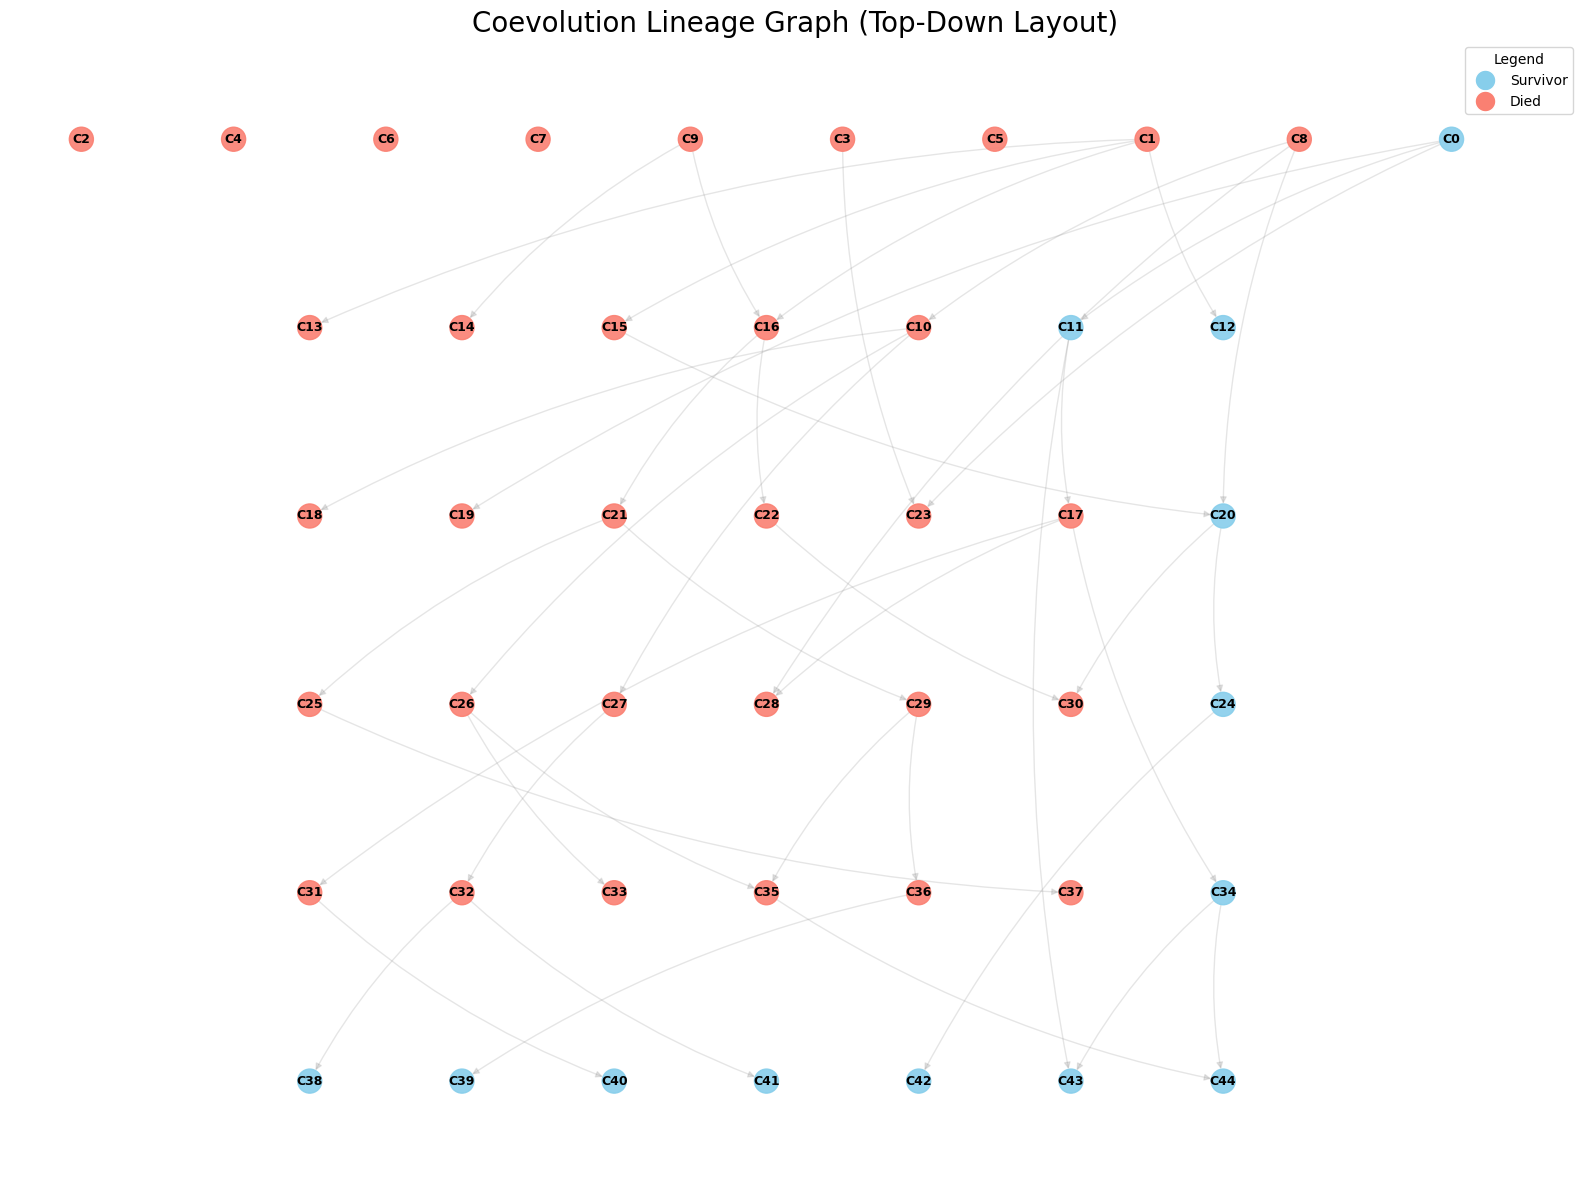

Generating lineage visualization (manual layout)...


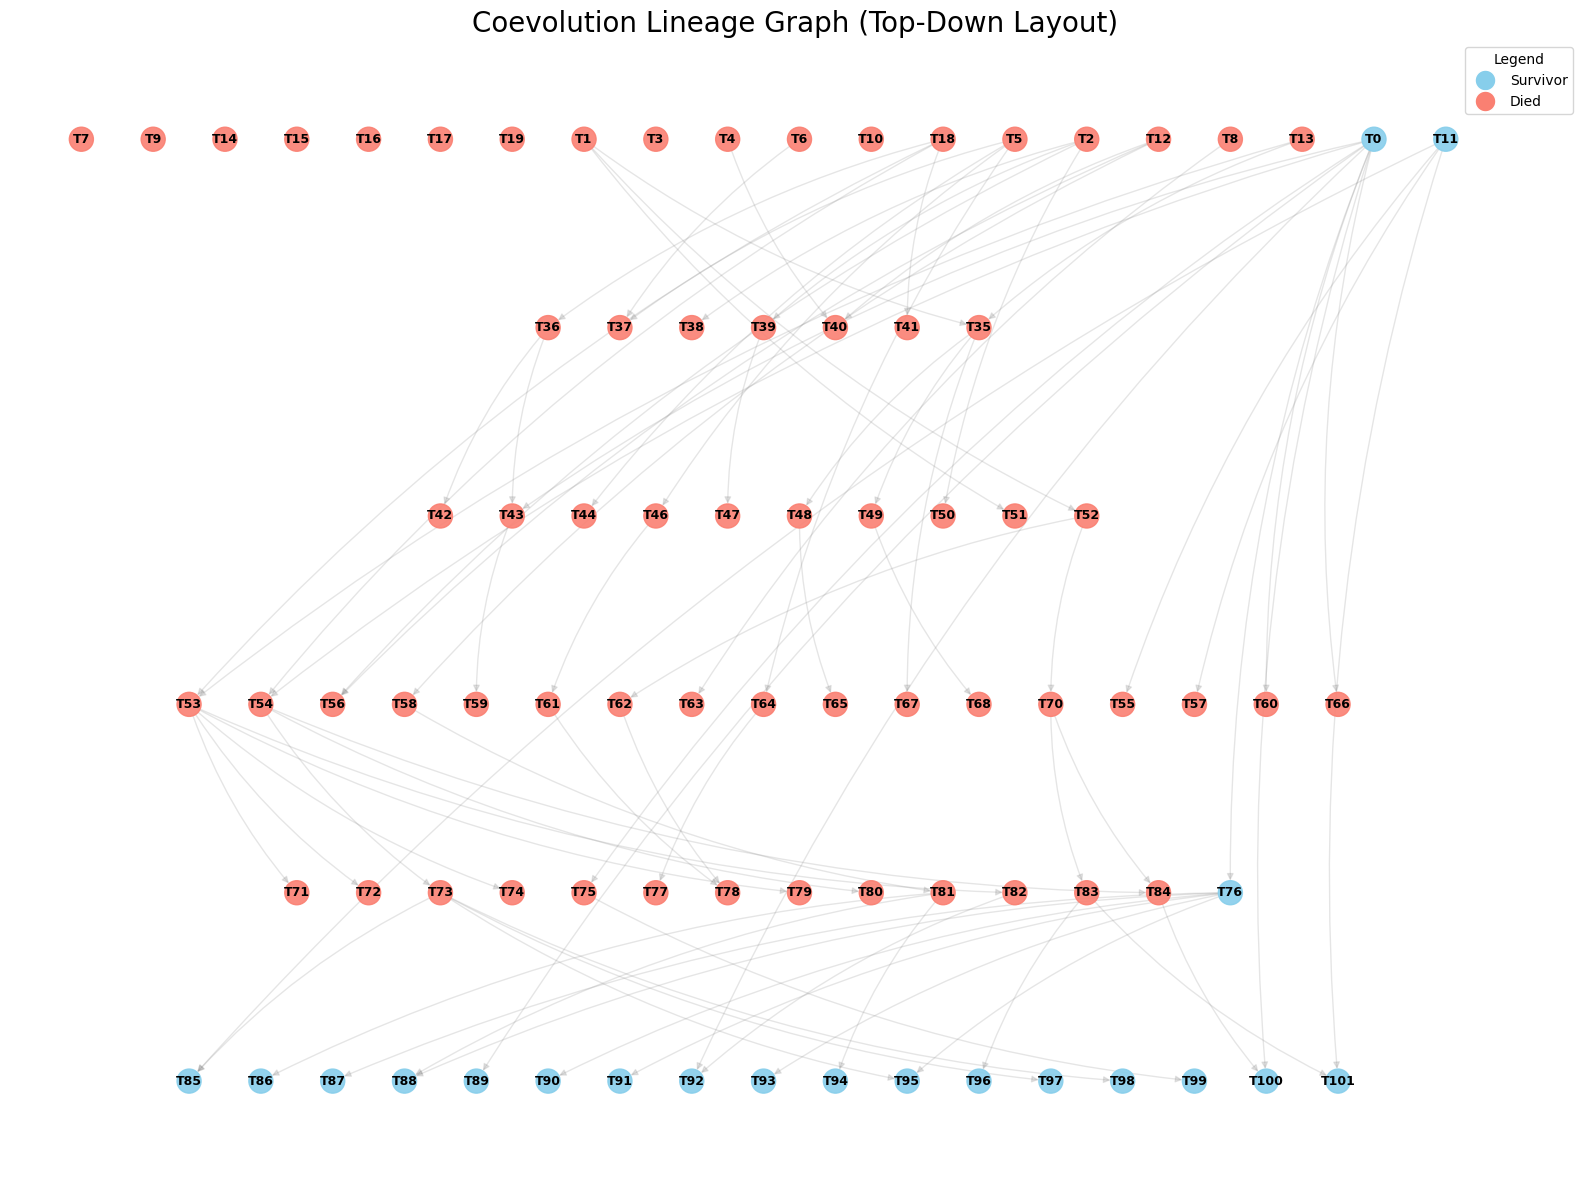

In [31]:
visualize_lineage(code_G)
visualize_lineage(test_G)

Plotting lifecycle timeline...


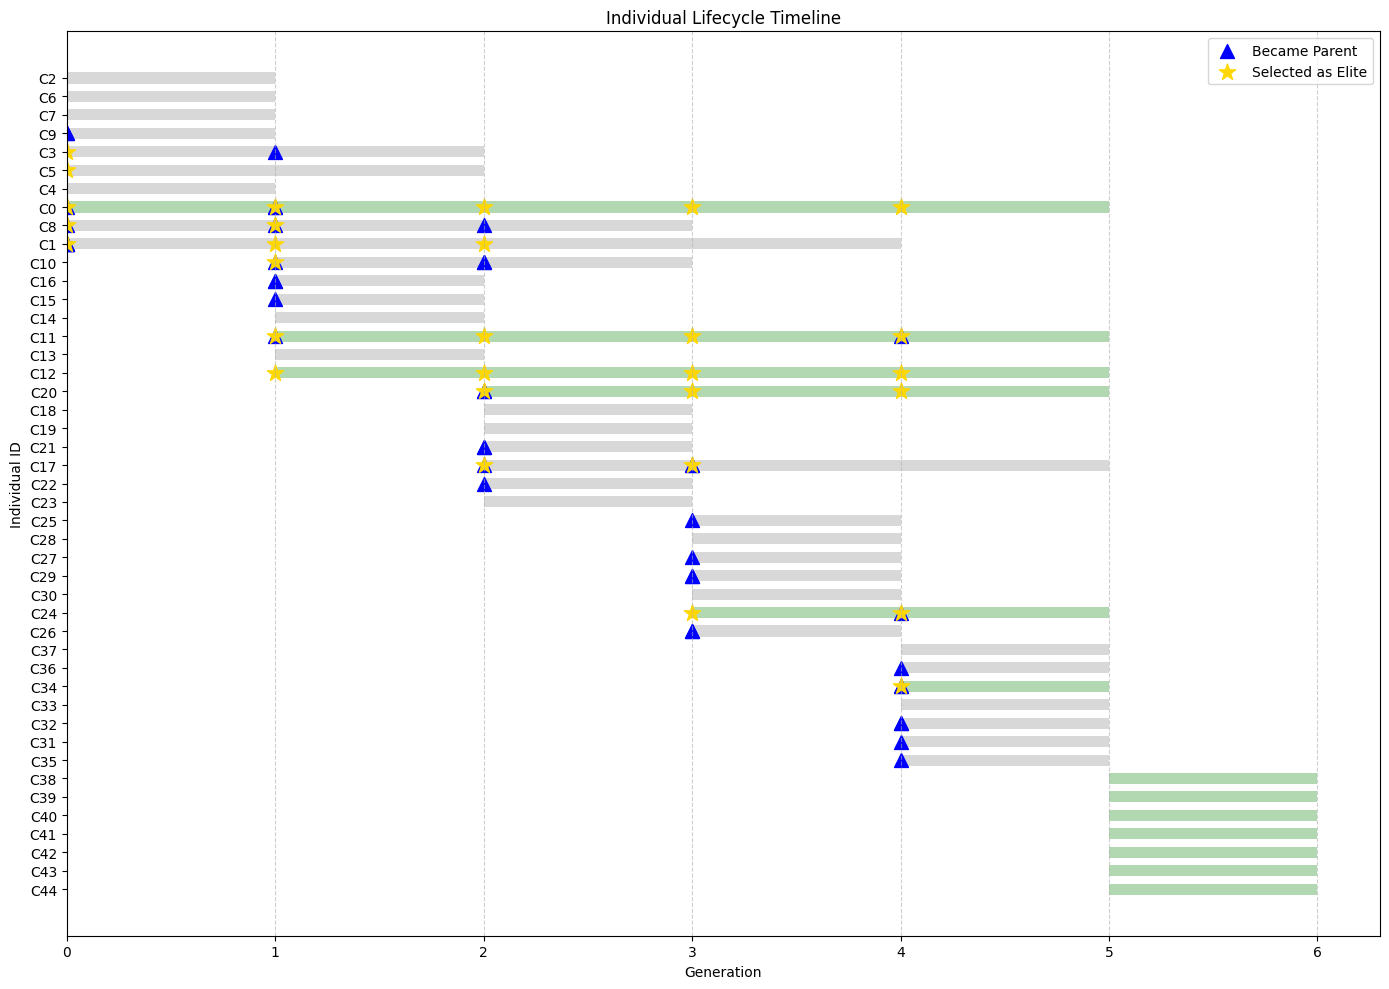

Plotting fitness evolution with labels...


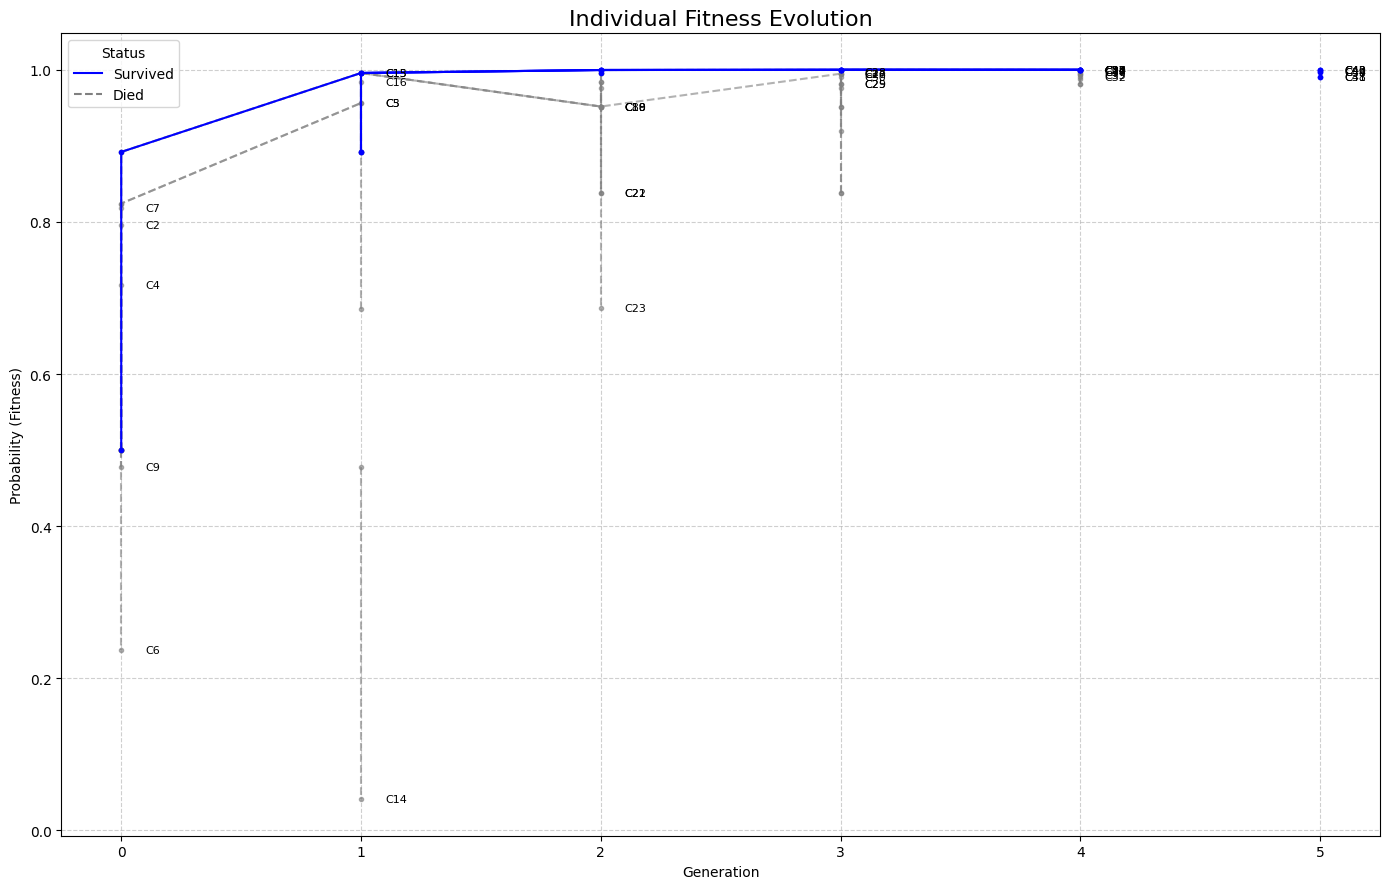

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def create_tidy_events_df(ind_df):
    """
    Un-nests the 'lifecycle_events' column from the main
    individual DataFrame into a tidy, flat DataFrame.
    """
    # 1. 'Explode' the list into new rows
    flat_df = ind_df.explode('lifecycle_events')

    # 2. Flatten the 'lifecycle_events' dictionary
    # Handle NaNs (for individuals with no events) gracefully
    flat_df['lifecycle_events'] = flat_df['lifecycle_events'].fillna({})
    event_series = flat_df['lifecycle_events'].apply(pd.Series)

    # 3. Flatten the 'details' dictionary
    # Handle empty details dicts (like for 'selected_as_elite')
    if 'details' not in event_series.columns:
        event_series['details'] = [{}] * len(event_series)
        
    event_series['details'] = event_series['details'].fillna({})
    details_series = event_series['details'].apply(pd.Series)

    # 4. Concatenate everything back together
    # --- THIS IS THE FIX ---
    # We drop both 'lifecycle_events' AND the conflicting 'probability' 
    # column from the original flat_df.
    final_df = pd.concat(
        [
            flat_df.drop(['lifecycle_events', 'probability'], axis=1), # <-- MODIFIED
            event_series.drop(['details'], axis=1),
            details_series
        ], 
        axis=1
    )
    
    # Clean up and reset the index
    final_df = final_df.reset_index(drop=True)
    
    # We need a numeric generation column for plotting
    if 'generation' in final_df.columns:
        final_df['generation'] = pd.to_numeric(final_df['generation'])
    
    return final_df

import pandas as pd
import matplotlib.pyplot as plt

def plot_fitness_evolution(tidy_events_df):
    """
    Plots the probability of each individual over generations.
    Instead of a color legend, it labels each line at its end.
    """
    
    # 1. Filter for events that have a probability value
    fitness_df = tidy_events_df[
        (tidy_events_df['event'] == 'probability_updated') | 
        (tidy_events_df['event'] == 'created')
    ].copy()
    
    # Ensure columns are numeric
    fitness_df['probability'] = pd.to_numeric(fitness_df['probability'])
    fitness_df['generation'] = pd.to_numeric(fitness_df['generation'])

    # 2. Get the final status (survived or died) for styling
    survivor_status = tidy_events_df.groupby('id')['status'].first().to_dict()

    print("Plotting fitness evolution with labels...")
    
    # 3. Create a matplotlib plot
    plt.figure(figsize=(14, 9))
    ax = plt.gca() # Get the current axes

    # 4. Loop through each individual
    all_ids = fitness_df['id'].unique()
    
    for ind_id in all_ids:
        # Get data for this individual, sorted by generation
        ind_data = fitness_df[fitness_df['id'] == ind_id].sort_values('generation')
        
        if ind_data.empty:
            continue
            
        x_data = ind_data['generation']
        y_data = ind_data['probability']
        
        # Get status to change line style
        status = survivor_status.get(ind_id, 'DIED')
        linestyle = '-' if status == 'SURVIVED' else '--'
        alpha = 1.0 if status == 'SURVIVED' else 0.6
        color = 'blue' if status == 'SURVIVED' else 'gray'

        # 5. Plot the individual's line
        ax.plot(
            x_data, 
            y_data, 
            marker='o', 
            markersize=3, 
            linestyle=linestyle, 
            alpha=alpha,
            color=color
        )
        
        # 6. Add the text label at the *end* of the line
        if not ind_data.empty:
            last_x = x_data.iloc[-1]
            last_y = y_data.iloc[-1]
            
            ax.text(
                last_x + 0.1,  # Small offset to the right
                last_y,        # At the same y-level
                ind_id,
                fontsize=8,    # Small font
                color='black',
                va='center'
            )

    ax.set_title('Individual Fitness Evolution', fontsize=16)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Probability (Fitness)')
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add a custom legend for line styles
    handles = [
        plt.Line2D([0], [0], color='blue', linestyle='-', label='Survived'),
        plt.Line2D([0], [0], color='gray', linestyle='--', label='Died')
    ]
    ax.legend(handles=handles, title="Status")
    
    plt.tight_layout()
    plt.show()


def plot_lifecycle_timeline(ind_df, tidy_events_df):
    """
    Plots a Gantt-style chart showing the lifespan and key
    events for each individual.
    """
    
    code_ind_df = ind_df[ind_df['type'] == 'CodeIndividual'].copy()
    
    # 1. Get the lifespan (start and end generation) for each individual
    # We sort by 'generation_born' so the chart is ordered
    lifespan_df = code_ind_df.sort_values(by='generation_born', ascending=False)
    
    # Get the last recorded generation for each individual
    last_gen = tidy_events_df.groupby('id')['generation'].max()
    lifespan_df['gen_end'] = lifespan_df['id'].map(last_gen)
    
    # Set a default end for any missing (shouldn't happen)
    lifespan_df['gen_end'] = lifespan_df['gen_end'].fillna(lifespan_df['generation_born'])
    
    # Calculate bar length
    lifespan_df['lifespan'] = lifespan_df['gen_end'] - lifespan_df['generation_born'] + 1
    
    # 2. Get the key events to plot as markers
    events_to_plot = tidy_events_df[
        tidy_events_df['event'].isin(['became_parent', 'selected_as_elite'])
    ]

    # --- 3. Plot ---
    print("Plotting lifecycle timeline...")
    fig, ax = plt.subplots(figsize=(14, 10))

    # Create a y-position for each individual
    id_list = lifespan_df['id'].tolist()
    y_pos = np.arange(len(id_list))

    # Plot the main lifespan bars
    ax.barh(
        y_pos,
        lifespan_df['lifespan'],
        left=lifespan_df['generation_born'],
        align='center',
        height=0.6,
        alpha=0.3,
        color=lifespan_df['status'].map({'SURVIVED': 'green', 'DIED': 'gray'})
    )

    # --- 4. Plot event markers ---
    
    # Map IDs to their y-position
    id_to_y = {id_name: y for id_name, y in zip(id_list, y_pos)}

    # Plot 'became_parent' events
    parent_events = events_to_plot[events_to_plot['event'] == 'became_parent']
    ax.scatter(
        parent_events['generation'],
        parent_events['id'].map(id_to_y),
        color='blue',
        marker='^',
        s=100,
        label='Became Parent'
    )

    # Plot 'selected_as_elite' events
    elite_events = events_to_plot[events_to_plot['event'] == 'selected_as_elite']
    ax.scatter(
        elite_events['generation'],
        elite_events['id'].map(id_to_y),
        color='gold',
        marker='*',
        s=150,
        label='Selected as Elite'
    )
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(id_list)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Individual ID')
    ax.set_title('Individual Lifecycle Timeline')
    ax.legend(loc='best')
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

tidy_code_events_df = create_tidy_events_df(ind_df[ind_df['type'] == 'CodeIndividual'])
plot_lifecycle_timeline(ind_df, tidy_code_events_df)
plot_fitness_evolution(tidy_code_events_df)


In [52]:
tidy_code_events_df[tidy_code_events_df['id'] == 'C0']

,id,type,snippet,creation_op,generation_born,parent_ids,status,run_id,problem_id,generation,event,creation_op,probability,offspring_id,operation
146,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,0,created,initial,0.500000,NaN,NaN
147,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,0,probability_updated,NaN,0.892002,NaN,NaN
148,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,0,selected_as_elite,NaN,NaN,NaN,NaN
149,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,0,became_parent,NaN,NaN,C11,edit
150,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,1,probability_updated,NaN,0.995804,NaN,NaN
151,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,1,selected_as_elite,NaN,NaN,NaN,NaN
152,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,1,became_parent,NaN,NaN,C19,edit
153,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,1,became_parent,NaN,NaN,C23,crossover
154,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,2,probability_updated,NaN,0.999733,NaN,NaN
155,C0,CodeIndividual,class Solution:\n def maxPartitionsAfterOpe...,initial,0,[],SURVIVED,test_012,3233,2,selected_as_elite,NaN,NaN,NaN,NaN
